# Domanda decisionale: dove intervenire contro la disoccupazione?

Dopo EDA e forecasting, trasformiamo gli output in una risposta concreta di policy.

**Domanda guida**

> Quali regioni italiane mostrano un rischio alto di disoccupazione nel 2025, considerando anche PIL, NEET e occupazione, e quale tipo di intervento pubblico/economico e piu coerente con il profilo del territorio?

Questa domanda collega direttamente il PIL ai predittori degli altri dataset: disoccupazione, occupati e NEET.

## Logica dell'analisi

Usiamo il forecast 2025 della disoccupazione prodotto dai modelli precedenti. Per evitare di usare informazione futura, il rischio 2025 e costruito con variabili 2024:

- disoccupazione prevista 2025;
- occupati 2024, per stimare quanti disoccupati potrebbero esserci;
- PIL 2024;
- PIL per occupato 2024, come proxy di produttivita/forza economica del territorio;
- NEET 2024, come segnale di fragilita giovanile.

Il risultato e una graduatoria di priorita e una proposta di azione per cluster territoriale.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import modeling, policy, utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Ricalcolo dei modelli e scelta del modello per la disoccupazione

In [2]:
samples = {
    "unemployment_rate": utils.build_forecasting_sample("unemployment_rate"),
    "employed_thousands": utils.build_forecasting_sample("employed_thousands"),
}
metrics, predictions = modeling.run_all_forecasts(samples, train_end_year=2023)
metrics

,target,model,n_test,MAE,RMSE,MAPE_%,R2
0,unemployment_rate,Random Forest,42,0.721845,0.951459,14.007192,0.924432
1,unemployment_rate,Gradient Boosting,42,0.739955,0.948016,13.815527,0.924978
2,unemployment_rate,ElasticNet ML lineare,42,0.853724,1.007570,17.703360,0.915256
3,unemployment_rate,Ridge ML lineare,42,0.877046,1.046907,18.811778,0.908510
4,unemployment_rate,OLS classica,42,0.911387,1.201389,17.419801,0.879517
5,unemployment_rate,Naive lag-1,42,0.955963,1.235682,14.854440,0.872541
6,employed_thousands,Naive lag-1,42,12.763524,20.398330,1.164368,0.999609
7,employed_thousands,Gradient Boosting,42,29.704593,48.851868,3.742047,0.997758
8,employed_thousands,Ridge ML lineare,42,31.937242,38.351651,7.453942,0.998618
9,employed_thousands,OLS classica,42,32.448285,40.119569,9.426271,0.998488


In [3]:
best_unemployment_model = (
    metrics.query("target == 'unemployment_rate'")
    .sort_values("MAE")
    .iloc[0]["model"]
)
best_unemployment_model

'Random Forest'

Nel nostro caso il miglior modello per la disoccupazione e non lineare. Questo e utile narrativamente: la relazione tra disoccupazione, NEET, PIL e territorio non sembra puramente lineare.

## 2. Costruzione della tabella di priorita

In [4]:
panel = utils.build_labour_panel(include_neet=True)
policy_table = policy.build_policy_table(
    panel,
    predictions,
    year=2025,
    unemployment_model=best_unemployment_model,
)

policy_path = PROCESSED_DIR / "policy_priority_table_2025.csv"
policy_table.to_csv(policy_path, index=False)

policy_table.head(10)

,REF_AREA,Territorio,year,pred_unemployment_rate,unemployment_rate,pred_unemployed_thousands,actual_unemployed_thousands,employed_thousands,gdp_lag1,gdp_per_employed_lag1,neet_rate_lag1,risk_score,policy_cluster,neet_flag
0,ITF3,Campania,2025,14.960743,14.251343,292.324288,282.596010,1700.347,137267.0,82.610444,24.903245,0.900000,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
1,ITG1,Sicilia,2025,13.032453,12.477971,213.705131,204.479007,1434.241,111704.4,78.329302,25.742155,0.897619,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
2,ITF6,Calabria,2025,13.066084,10.210476,78.306403,60.974002,536.197,39858.2,76.502676,26.232599,0.897619,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
3,ITF4,Puglia,2025,8.854730,10.273240,123.129496,143.698999,1255.071,94488.9,74.552102,21.419766,0.876190,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
4,ITG2,Sardegna,2025,7.459169,9.532401,46.061768,60.282999,572.118,43437.6,76.012018,17.787085,0.769048,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
5,ITF2,Molise,2025,7.386611,6.356495,8.323571,7.032000,103.595,7990.8,76.568833,18.960077,0.669048,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
6,ITF1,Abruzzo,2025,6.545192,6.762283,34.525042,35.819002,493.869,40755.5,82.674729,17.217976,0.621429,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
7,ITF5,Basilicata,2025,6.697985,5.510016,13.616717,11.212001,192.272,15106.1,79.640340,17.036644,0.607143,Priorita alta: disoccupazione alta e PIL per o...,NEET alto
8,ITE4,Lazio,2025,5.222215,5.680821,128.612314,140.814938,2337.963,246569.4,105.634270,15.155948,0.580952,Mismatch: disoccupazione alta ma base economic...,NEET alto
9,ITE3,Marche,2025,4.823735,5.290068,31.325102,34.578001,619.062,50595.3,81.860145,10.589946,0.509524,Priorita alta: disoccupazione alta e PIL per o...,NEET sotto mediana


Lo score non e una previsione statistica autonoma: e un indice decisionale. Serve a mettere insieme rischio di disoccupazione, fragilita giovanile, massa potenziale di disoccupati e debolezza produttiva.

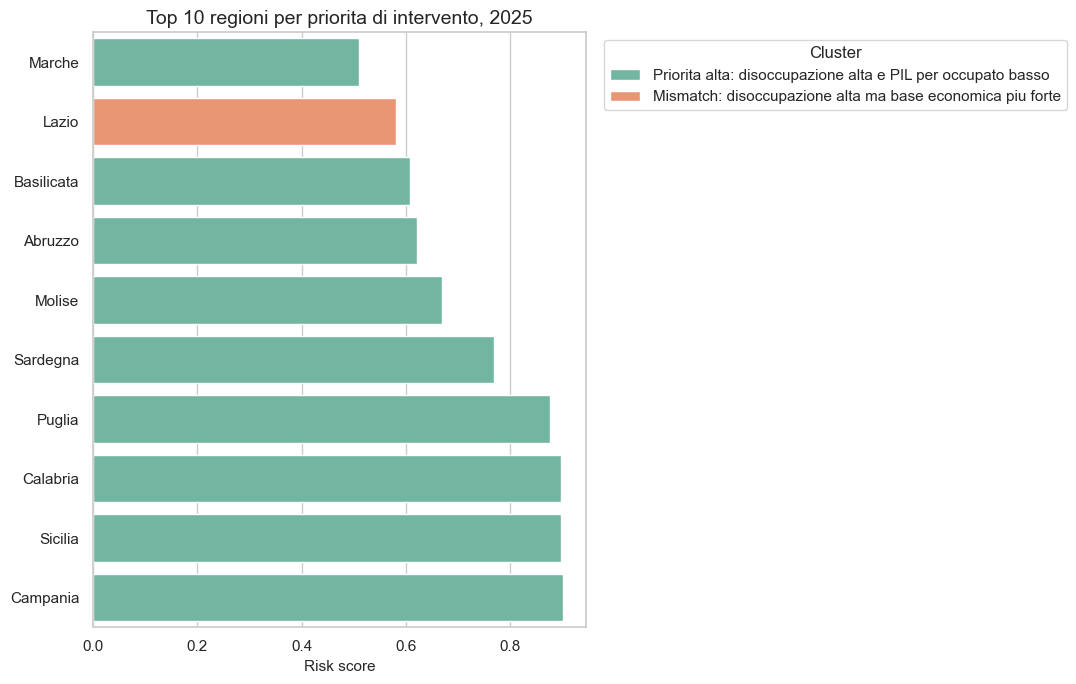

In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
top = policy_table.head(10).sort_values("risk_score")
sns.barplot(data=top, x="risk_score", y="Territorio", hue="policy_cluster", dodge=False, ax=ax)
ax.set_title("Top 10 regioni per priorita di intervento, 2025")
ax.set_xlabel("Risk score")
ax.set_ylabel("")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "policy_priority_ranking_2025.png", dpi=150)
plt.show()

## 3. PIL per occupato e disoccupazione prevista

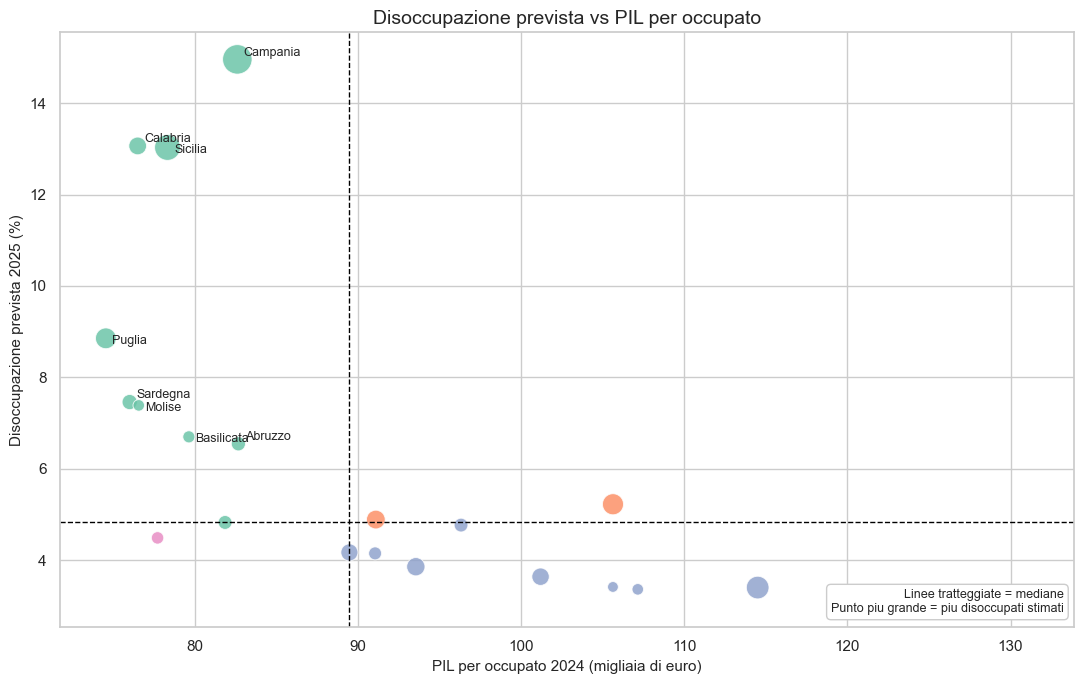

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=policy_table,
    x="gdp_per_employed_lag1",
    y="pred_unemployment_rate",
    size="pred_unemployed_thousands",
    hue="policy_cluster",
    sizes=(60, 450),
    alpha=0.82,
    legend=False,
    ax=ax,
)
for i, (_, row) in enumerate(policy_table.head(8).iterrows()):
    offset_y = 0.08 if i % 2 == 0 else -0.12
    ax.text(row["gdp_per_employed_lag1"] + 0.4, row["pred_unemployment_rate"] + offset_y, row["Territorio"], fontsize=9)
ax.axhline(policy_table["pred_unemployment_rate"].median(), color="black", linewidth=1, linestyle="--")
ax.axvline(policy_table["gdp_per_employed_lag1"].median(), color="black", linewidth=1, linestyle="--")
ax.set_title("Disoccupazione prevista vs PIL per occupato")
ax.set_xlabel("PIL per occupato 2024 (migliaia di euro)")
ax.set_ylabel("Disoccupazione prevista 2025 (%)")
ax.text(
    0.99,
    0.02,
    "Linee tratteggiate = mediane\nPunto piu grande = piu disoccupati stimati",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#CCCCCC"},
)
plt.tight_layout()
plt.savefig(FIG_DIR / "policy_gdp_unemployment_quadrants.png", dpi=150)
plt.show()

## 4. Risposta concreta: dove agire e come

In [7]:
recommendations = policy_table.head(8).copy()
recommendations["azione_consigliata"] = recommendations.apply(policy.recommend_action, axis=1)
recommendations[
    [
        "Territorio",
        "pred_unemployment_rate",
        "unemployment_rate",
        "pred_unemployed_thousands",
        "gdp_per_employed_lag1",
        "neet_rate_lag1",
        "policy_cluster",
        "azione_consigliata",
    ]
]

,Territorio,pred_unemployment_rate,unemployment_rate,pred_unemployed_thousands,gdp_per_employed_lag1,neet_rate_lag1,policy_cluster,azione_consigliata
0,Campania,14.960743,14.251343,292.324288,82.610444,24.903245,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
1,Sicilia,13.032453,12.477971,213.705131,78.329302,25.742155,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
2,Calabria,13.066084,10.210476,78.306403,76.502676,26.232599,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
3,Puglia,8.854730,10.273240,123.129496,74.552102,21.419766,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
4,Sardegna,7.459169,9.532401,46.061768,76.012018,17.787085,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
5,Molise,7.386611,6.356495,8.323571,76.568833,18.960077,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
6,Abruzzo,6.545192,6.762283,34.525042,82.674729,17.217976,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...
7,Basilicata,6.697985,5.510016,13.616717,79.640340,17.036644,Priorita alta: disoccupazione alta e PIL per o...,Intervento integrato: incentivi a investimenti...


### Sintesi interpretativa

Le aree che richiedono piu attenzione sono quelle in cui convivono:

- disoccupazione prevista alta;
- molti disoccupati potenziali in valore assoluto;
- PIL per occupato sotto la mediana;
- NEET elevato.

Questo profilo indica che non basta una politica generica di ricerca lavoro: serve rafforzare sia la domanda di lavoro, cioe imprese e investimenti, sia l'offerta di competenze.

In [8]:
priority_regions = recommendations["Territorio"].tolist()
print("Regioni prioritarie:", ", ".join(priority_regions[:5]))

answer = f"""
Risposta di policy:

Le prime aree su cui intervenire sono {', '.join(priority_regions[:5])}. 
Il motivo e che combinano disoccupazione prevista elevata, NEET alto e PIL per occupato relativamente basso. 
In queste regioni il problema non sembra solo congiunturale: il mercato del lavoro assorbe poco e la base produttiva e meno capace di generare occupazione stabile.

Azione consigliata:
1. usare incentivi e fondi regionali/europei per attrarre investimenti produttivi nei settori con domanda;
2. collegare formazione tecnica, ITS e apprendistato ai fabbisogni delle imprese locali;
3. rafforzare politiche attive e centri per l'impiego con target specifico sui giovani NEET;
4. monitorare annualmente se PIL per occupato e occupazione migliorano, non solo se scende il tasso di disoccupazione.
"""
print(answer)

Regioni prioritarie: Campania, Sicilia, Calabria, Puglia, Sardegna

Risposta di policy:

Le prime aree su cui intervenire sono Campania, Sicilia, Calabria, Puglia, Sardegna. 
Il motivo e che combinano disoccupazione prevista elevata, NEET alto e PIL per occupato relativamente basso. 
In queste regioni il problema non sembra solo congiunturale: il mercato del lavoro assorbe poco e la base produttiva e meno capace di generare occupazione stabile.

Azione consigliata:
1. usare incentivi e fondi regionali/europei per attrarre investimenti produttivi nei settori con domanda;
2. collegare formazione tecnica, ITS e apprendistato ai fabbisogni delle imprese locali;
3. rafforzare politiche attive e centri per l'impiego con target specifico sui giovani NEET;
4. monitorare annualmente se PIL per occupato e occupazione migliorano, non solo se scende il tasso di disoccupazione.



## 5. Come raccontarlo nel progetto

Una formulazione efficace per la presentazione:

> I modelli ML non lineari prevedono meglio la disoccupazione rispetto alla regressione classica. Tuttavia, il risultato diventa utile solo se viene trasformato in priorita territoriali. Incrociando forecast della disoccupazione, PIL per occupato, NEET e numero stimato di disoccupati, emergono regioni in cui la risposta deve combinare investimenti produttivi e politiche attive del lavoro. Per gli occupati, invece, la baseline dell'anno precedente e molto forte: questo suggerisce che l'occupazione regionale e persistente e che la semplice complessita modellistica non basta a migliorare il forecast.

Questa parte risponde alla domanda: non solo "quanto prevedo", ma "dove agire e con quale leva".